# Cross-Source PropAMM Quote Ladder Analysis

Polaris normalizes on-chain proprietary AMM observations into one
[PropAMM Quote Ladders](https://docs.polaris.supply/schemas/propamm-quote-ladders) schema. This
notebook checks all six documented sources, selects a directed token pair shared by the most sources,
and compares observed quote curves and price impact without losing uint256 precision. Recorded
ladder bounds are treated as probe ranges, not as evidence of executable liquidity.


## Setup

Quote ladders are sparse block-level events. Each source is queried over up to the first hour of
its no-key preview day, with a 5,000-row cap.


In [1]:
from decimal import Decimal
from itertools import product
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from polaris_data import PolarisClient

for _candidate in (Path.cwd() / "notebooks", Path.cwd()):
    if (_candidate / "_polaris.py").exists():
        sys.path.insert(0, str(_candidate))
        break

from _polaris import accessible_bounds, bounded_rows, event_timestamp

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
warnings.filterwarnings("ignore", message=r".*snapshot coverage.*", category=UserWarning)


In [2]:
sources = ["fermiswap", "bopamm", "kipseli", "metric", "tempest", "taurusfi"]
market = "ethereum"
window_length = pd.Timedelta(hours=1)
max_rows_per_source = 5_000
max_block_skew = 12
max_time_skew = pd.Timedelta(minutes=2)
baseline_input_target = Decimal("0.01")
representative_inputs = [Decimal("0.01"), Decimal("1"), Decimal("10")]


## Discover and fetch each source

Empty sources remain in the coverage table so absence in a short public window is not confused with
an unsupported schema.


In [3]:
rows_by_source = {}
coverage_records = []

with PolarisClient() as client:
    for source in sources:
        catalog = client.catalog(source=source, market=market)
        if not catalog.get("markets"):
            rows_by_source[source] = []
            coverage_records.append({"source": source, "rows": 0, "hit_cap": False, "window": "not in catalog"})
            continue

        market_info = catalog["markets"][0]
        start, accessible_end = accessible_bounds(market_info)
        end = min(start + window_length, accessible_end)
        rows, truncated = bounded_rows(
            client.propamm_quote_ladders(
                source=source, market=market, from_=start, to=end, allow_gaps=True,
            ),
            max_rows_per_source,
        )
        rows_by_source[source] = rows
        coverage_records.append({
            "source": source,
            "rows": len(rows),
            "hit_cap": truncated,
            "window": f"{start} -> {end}",
        })

coverage_df = pd.DataFrame(coverage_records)
coverage_df


,source,rows,hit_cap,window
0,fermiswap,138,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00
1,bopamm,4,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00
2,kipseli,44,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00
3,metric,1360,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00
4,tempest,120,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00
5,taurusfi,0,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 01:00:00+00:00


## Inspect event identity and select a comparable pair

Comparison is restricted to the same token direction. A pair seen across the most sources wins;
ties prefer the pair with the most quote observations. If only one source is populated, its richest
pair still produces a complete single-source analysis.


In [4]:
ladder_records = []
for source, rows in rows_by_source.items():
    for row in rows:
        values = (row.get("data") or {}).get("values") or {}
        ladder_records.append({
            "source": source,
            "participant": (
                source if not values.get("pool") else f"{source}:{values['pool'].lower()}"
            ),
            "timestamp": event_timestamp(row),
            "collector_sequence": row.get("collector_sequence"),
            "chain_id": values.get("chain_id"),
            "token_in": (values.get("token_in") or "").lower(),
            "token_out": (values.get("token_out") or "").lower(),
            "token_in_decimals": values.get("token_in_decimals"),
            "token_out_decimals": values.get("token_out_decimals"),
            "quotes": values.get("quotes") or [],
            "event_id": values.get("event_id"),
            "block_number": values.get("block_number"),
            "block_hash": values.get("block_hash"),
            "parent_hash": values.get("parent_hash"),
            "transaction_hash": values.get("transaction_hash"),
            "transaction_index": values.get("transaction_index"),
            "router": values.get("router"),
            "oracle": values.get("oracle"),
            "pool": values.get("pool"),
        })

ladders_df = pd.DataFrame(ladder_records)
if ladders_df.empty:
    raise ValueError("No PropAMM quote ladders were found in the public sample windows")

pair_coverage = (
    ladders_df.groupby(["token_in", "token_out"])
    .agg(sources=("source", "nunique"), ladders=("source", "size"), quote_points=("quotes", lambda values: sum(map(len, values))))
    .sort_values(["sources", "quote_points", "ladders"], ascending=False)
)
selected_pair = pair_coverage.index[0]
print(f"Selected directed pair: {selected_pair[0]} -> {selected_pair[1]}")
pair_coverage.head(10)


Selected directed pair: 0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 -> 0xdac17f958d2ee523a2206206994597c13d831ec7


,,sources,ladders,quote_points
token_in,token_out,,,
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0xdac17f958d2ee523a2206206994597c13d831ec7,3,109,10267
0xdac17f958d2ee523a2206206994597c13d831ec7,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,3,109,9107
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,3,60,6449
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,3,60,5756
0x2260fac5e5542a773aa44fbcfedf7c193bc2c599,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,3,21,2585
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,0x2260fac5e5542a773aa44fbcfedf7c193bc2c599,3,21,2387
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0xdac17f958d2ee523a2206206994597c13d831ec7,2,42,3606
0xdac17f958d2ee523a2206206994597c13d831ec7,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,2,42,3503
0x9d39a5de30e57443bff2a8307a4256c8797a3497,0x4c9edd5852cd905f086c759e8383e09bff1e68b3,1,85,18275


## Align ladders and compare exact shared input sizes

The least frequently observed participant is used as the cohort anchor. For each of its ladders,
the nearest ladder from every other participant is retained only when the whole cohort fits the
configured block and observation-time skew. Metric pools remain separate participants.

Amounts stay as `Decimal`. Comparisons use exact input amounts shared by every participant and a
common economically meaningful baseline. This avoids using tiny, output-quantized quotes as the
price-impact reference. `recorded_max_probe` is only the largest sampled input—not capacity.


In [5]:
def align_nearest_ladders(pair_ladders):
    """Build unique, complete nearest-block cohorts within explicit skew limits."""
    pair_ladders = pair_ladders.dropna(subset=["block_number", "timestamp"]).copy()
    participant_counts = pair_ladders.groupby("participant").size()
    participants = sorted(participant_counts.index)
    minimum_count = participant_counts.min()
    anchor_participant = sorted(participant_counts[participant_counts.eq(minimum_count)].index)[0]
    aligned_records = []
    cohort_records = []
    seen_event_sets = set()

    for _, anchor in pair_ladders[pair_ladders["participant"].eq(anchor_participant)].iterrows():
        candidate_groups = []
        for participant in participants:
            if participant == anchor_participant:
                candidate_groups.append([anchor])
                continue
            candidates = pair_ladders[pair_ladders["participant"].eq(participant)]
            candidates = candidates[
                (candidates["block_number"] - anchor["block_number"]).abs().le(max_block_skew)
                & (candidates["timestamp"] - anchor["timestamp"]).abs().le(max_time_skew)
            ]
            candidate_groups.append([candidate for _, candidate in candidates.iterrows()])

        if any(not candidates for candidates in candidate_groups):
            continue
        valid_combinations = []
        for combination in product(*candidate_groups):
            block_span = int(max(member["block_number"] for member in combination) - min(member["block_number"] for member in combination))
            time_span = max(member["timestamp"] for member in combination) - min(member["timestamp"] for member in combination)
            if block_span <= max_block_skew and time_span <= max_time_skew:
                total_block_distance = sum(abs(member["block_number"] - anchor["block_number"]) for member in combination)
                total_time_distance = sum((abs(member["timestamp"] - anchor["timestamp"]) for member in combination), pd.Timedelta(0))
                valid_combinations.append((block_span, time_span, total_block_distance, total_time_distance, combination))
        if not valid_combinations:
            continue
        _, time_span, _, _, members = min(valid_combinations, key=lambda candidate: candidate[:4])
        block_span = int(max(member["block_number"] for member in members) - min(member["block_number"] for member in members))

        event_set = tuple(sorted(member["event_id"] for member in members))
        if event_set in seen_event_sets:
            continue
        seen_event_sets.add(event_set)
        cohort_id = len(cohort_records)

        cohort_records.append({
            "cohort_id": cohort_id,
            "anchor_participant": anchor_participant,
            "anchor_block": int(anchor["block_number"]),
            "anchor_timestamp": anchor["timestamp"],
            "block_span": block_span,
            "time_span_seconds": time_span.total_seconds(),
        })
        for member in members:
            record = member.drop(labels=["_block_distance", "_time_distance"], errors="ignore").to_dict()
            record.update({
                "cohort_id": cohort_id,
                "block_offset": int(member["block_number"] - anchor["block_number"]),
                "time_offset_seconds": (member["timestamp"] - anchor["timestamp"]).total_seconds(),
            })
            aligned_records.append(record)

    if not cohort_records:
        raise ValueError("No complete quote-ladder cohorts satisfy the configured skew limits")
    return pd.DataFrame(aligned_records), pd.DataFrame(cohort_records)


def compare_exact_shared_inputs(cohort_ladders):
    """Normalize one cohort and calculate level and curve metrics on exact shared sizes."""
    quote_records = []
    probe_records = []
    for _, ladder in cohort_ladders.iterrows():
        input_scale = Decimal(10) ** int(ladder["token_in_decimals"])
        output_scale = Decimal(10) ** int(ladder["token_out_decimals"])
        participant_quotes = []
        for quote in ladder["quotes"]:
            amount_in = Decimal(quote["amount_in"]) / input_scale
            amount_out = Decimal(quote["amount_out"]) / output_scale
            if amount_in <= 0:
                continue
            participant_quotes.append((amount_in, amount_out))
            quote_records.append({
                "cohort_id": ladder["cohort_id"],
                "source": ladder["source"],
                "participant": ladder["participant"],
                "amount_in": amount_in,
                "amount_out": amount_out,
                "average_rate": amount_out / amount_in,
            })
        if not participant_quotes:
            raise ValueError(f"{ladder['participant']} has no positive quote inputs")
        probe_records.append({
            "cohort_id": ladder["cohort_id"],
            "source": ladder["source"],
            "participant": ladder["participant"],
            "recorded_quote_points": len(participant_quotes),
            "recorded_min_probe": min(amount for amount, _ in participant_quotes),
            "recorded_max_probe": max(amount for amount, _ in participant_quotes),
        })

    normalized = pd.DataFrame(quote_records)
    input_sets = [set(values["amount_in"]) for _, values in normalized.groupby("participant")]
    exact_shared_inputs = sorted(set.intersection(*input_sets))
    eligible_inputs = [amount for amount in exact_shared_inputs if amount >= baseline_input_target]
    if not eligible_inputs:
        raise ValueError("No exact shared input meets the configured baseline target")

    baseline_input = eligible_inputs[0]
    compared = normalized[normalized["amount_in"].isin(eligible_inputs)].copy()
    baseline_rates = (
        compared[compared["amount_in"].eq(baseline_input)]
        .set_index("participant")["average_rate"]
    )
    best_rates = compared.groupby("amount_in")["average_rate"].max()
    compared["baseline_rate"] = compared["participant"].map(baseline_rates)
    compared["best_rate"] = compared["amount_in"].map(best_rates)
    compared["quote_edge_bps"] = compared.apply(
        lambda row: (row["average_rate"] / row["best_rate"] - Decimal(1)) * Decimal(10_000), axis=1
    )
    compared["curve_impact_bps"] = compared.apply(
        lambda row: (row["average_rate"] / row["baseline_rate"] - Decimal(1)) * Decimal(10_000), axis=1
    )
    for column in ["amount_in", "amount_out", "average_rate", "quote_edge_bps", "curve_impact_bps"]:
        compared[f"{column}_float"] = compared[column].astype(float)

    details = {
        "exact_shared_points": len(exact_shared_inputs),
        "shared_min_input": exact_shared_inputs[0],
        "shared_max_input": exact_shared_inputs[-1],
        "baseline_input": baseline_input,
        "analysis_points": len(eligible_inputs),
    }
    return compared, pd.DataFrame(probe_records), details


pair_ladders = ladders_df[
    ladders_df["token_in"].eq(selected_pair[0]) & ladders_df["token_out"].eq(selected_pair[1])
].copy()
aligned_ladders, cohort_summary = align_nearest_ladders(pair_ladders)

comparison_frames = []
probe_frames = []
comparison_details = []
for cohort_id, cohort_ladders in aligned_ladders.groupby("cohort_id"):
    compared, probes, details = compare_exact_shared_inputs(cohort_ladders)
    comparison_frames.append(compared)
    probe_frames.append(probes)
    comparison_details.append({"cohort_id": cohort_id, **details})

all_comparisons = pd.concat(comparison_frames, ignore_index=True)
all_probe_ranges = pd.concat(probe_frames, ignore_index=True)
cohort_summary = cohort_summary.merge(pd.DataFrame(comparison_details), on="cohort_id")
selected_cohort_id = cohort_summary.sort_values("anchor_timestamp").iloc[-1]["cohort_id"]
selected_ladders = aligned_ladders[aligned_ladders["cohort_id"].eq(selected_cohort_id)].copy()
quotes_df = all_comparisons[all_comparisons["cohort_id"].eq(selected_cohort_id)].copy()
probe_summary = all_probe_ranges[all_probe_ranges["cohort_id"].eq(selected_cohort_id)].copy()

metadata_columns = [
    "participant", "timestamp", "block_number", "block_offset", "time_offset_seconds",
    "transaction_hash", "router", "oracle", "pool", "event_id",
]
display(cohort_summary)
display(selected_ladders[metadata_columns].sort_values("participant"))
display(probe_summary.drop(columns="cohort_id").set_index("participant"))

available_representative_inputs = sorted(
    set(amount for amount in representative_inputs if amount in set(quotes_df["amount_in"]))
    | {quotes_df["amount_in"].max()}
)
representative = quotes_df[quotes_df["amount_in"].isin(available_representative_inputs)]
representative_comparison = pd.concat({
    "amount_out": representative.pivot(index="amount_in", columns="participant", values="amount_out_float"),
    "quote_edge_bps": representative.pivot(index="amount_in", columns="participant", values="quote_edge_bps_float"),
}, axis=1)
display(representative_comparison)

cross_cohort_summary = all_comparisons.groupby("participant").agg(
    aligned_observations=("cohort_id", "nunique"),
    shared_quote_points=("amount_in", "size"),
    quote_point_win_rate=("quote_edge_bps_float", lambda values: values.abs().lt(1e-9).mean()),
    median_quote_edge_bps=("quote_edge_bps_float", "median"),
    p05_quote_edge_bps=("quote_edge_bps_float", lambda values: values.quantile(0.05)),
    median_curve_impact_bps=("curve_impact_bps_float", "median"),
    worst_curve_impact_bps=("curve_impact_bps_float", "min"),
)
cross_cohort_summary


,cohort_id,anchor_participant,anchor_block,anchor_timestamp,block_span,time_span_seconds,exact_shared_points,shared_min_input,shared_max_input,baseline_input,analysis_points
0,0,fermiswap,25871714,2026-08-31 00:36:14.346000+00:00,0,0.000,49,0.01,4000,0.01,49
1,1,fermiswap,25871720,2026-08-31 00:37:32.703000+00:00,6,78.357,49,0.01,4000,0.01,49


,participant,timestamp,block_number,block_offset,time_offset_seconds,transaction_hash,router,oracle,pool,event_id
3,fermiswap,2026-08-31 00:37:32.703000+00:00,25871720,0,0.000,0x6f3271b0c34f842529293a033936de0eadfd6990fc477b79ca187d96656a90fb,0x5979458912F80B96d30D4220af8E2e4925A33320,0x5B56042558012d21Fd3578C8b1d4519196517241,NaN,0x1df5537fd08f553c952568f1c06412873071ede5b37220b6c32350bc1c4c31ee:0x6f3271b0c34f842529293a03393...
4,metric:0x7718360ead37485836e7fa69deae10058813baf1,2026-08-31 00:36:43.397000+00:00,25871716,-4,-49.306,0x55a0cdbd6a83b184d185d344dc8aa65d2c74fb6ccce7203bf9282800f9022a76,0xcB41C10c6414aCbea022c7662df4005dd8FBEF91,0x28d9CCEDf1B7ac9B3F090f4F0292837dE87c1D39,0x7718360ead37485836e7fa69DEaE10058813baf1,0xe5b1196bd6f3e4eaa6f5fa8ed565f7e37a01c4f89fea91f1999b7d31ef6683b4:0x55a0cdbd6a83b184d185d344dc8...
5,tempest,2026-08-31 00:36:14.346000+00:00,25871714,-6,-78.357,0xf3d805240fc7a0ea303aa544fee12e73d5fefaede403637f0591727c174baef1,0x00000003f1ec2379e79F58E12EC6C4F51Ee92149,0x00000003f1ec2379e79F58E12EC6C4F51Ee92149,NaN,0xf93f5e5330cba891592f49337b488161829bd9d2136836dcf0be905308cf4991:0xf3d805240fc7a0ea303aa544fee...


,source,recorded_quote_points,recorded_min_probe,recorded_max_probe
participant,,,,
fermiswap,fermiswap,74,0.01,1339152.533338
metric:0x7718360ead37485836e7fa69deae10058813baf1,metric,88,0.000001,6588.994498
tempest,tempest,86,0.000001,4552.585426


amount_out                                                    \
participant    fermiswap metric:0x7718360ead37485836e7fa69deae10058813baf1   
amount_in                                                                    
0.01            0.010000                                          0.010000   
1               1.000069                                          1.000063   
10             10.000695                                         10.000638   
4000         4000.278080                                       4000.254371   

                         quote_edge_bps  \
participant      tempest      fermiswap   
amount_in                                 
0.01            0.010000            0.0   
1               1.000019            0.0   
10             10.000199            0.0   
4000         4000.079984            0.0   

                                                                         
participant metric:0x7718360ead37485836e7fa69deae10058813baf1   tempest  
amount_in                                                                
0.01                                                 0.000000  0.000000  
1                                                   -0.059996 -0.499966  
10                                                  -0.056996 -0.495966  
4000                                                -0.059268 -0.495206

,aligned_observations,shared_quote_points,quote_point_win_rate,median_quote_edge_bps,p05_quote_edge_bps,median_curve_impact_bps,worst_curve_impact_bps
participant,,,,,,,
fermiswap,2,98,0.591837,0.000000,-0.018299,0.690225,0.0
metric:0x7718360ead37485836e7fa69deae10058813baf1,2,98,0.571429,0.000000,-0.059996,0.638362,0.0
tempest,2,98,0.020408,-0.499975,-0.562184,0.198571,0.0


## Shared-size quote level and price impact

The latest valid cohort is plotted only on exact shared inputs at or above the common baseline.
Quote edge measures each participant against the best observed output at the same input size; curve
impact measures its rate change from the common baseline. A quote remains an observation, not proof
that the same amount can be settled later; capacity requires venue-aware transaction simulation or
settlement evidence.


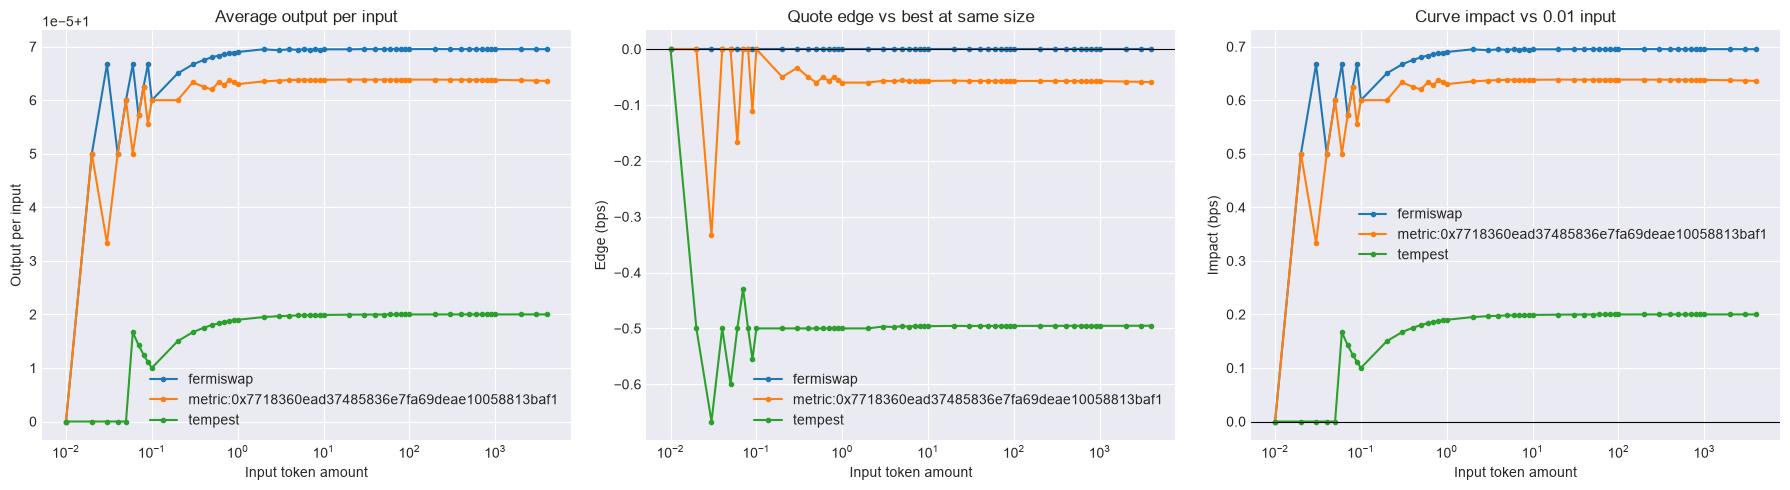

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for source, values in quotes_df.groupby("participant"):
    values = values.sort_values("amount_in_float")
    axes[0].plot(values["amount_in_float"], values["average_rate_float"], marker=".", label=source)
    axes[1].plot(values["amount_in_float"], values["quote_edge_bps_float"], marker=".", label=source)
    axes[2].plot(values["amount_in_float"], values["curve_impact_bps_float"], marker=".", label=source)

for axis in axes:
    axis.set_xscale("log")
    axis.set_xlabel("Input token amount")
    axis.legend()
axes[0].set_title("Average output per input")
axes[0].set_ylabel("Output per input")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Quote edge vs best at same size")
axes[1].set_ylabel("Edge (bps)")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title(f"Curve impact vs {quotes_df['amount_in'].min()} input")
axes[2].set_ylabel("Impact (bps)")

plt.tight_layout()
plt.show()


## PropAMM Aggregate Trade Analytics

Polaris also normalizes execution-level records for these venues as `type="trade"`
events via `client.trades(...)`. Each fill carries `price`, `quantity`, `side`, and an
`order_id` (`transaction_hash:log_index`). Unlike quote ladders, the standardized trade
record does **not** carry `token_in`, `token_out`, or `pool`, so an individual fill cannot
be attributed to a specific pair from the trade stream alone. Pair context below is drawn
from the full-day quote-ladder observations (which do carry directed pairs and Metric pools).

Volume is `price x quantity`. For pairs quoted against USDC/USDT this is the USD notional;
for non-USD pairs (e.g. WBTC/WETH) the same product is in quote-token terms.

In [7]:
TOKEN_SYMBOLS = {
    "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2": "WETH",
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": "USDC",
    "0xdac17f958d2ee523a2206206994597c13d831ec7": "USDT",
    "0x2260fac5e5542a773aa44fbcfedf7c193bc2c599": "WBTC",
    "0x9d39a5de30e57443bff2a8307a4256c8797a3497": "sUSDe",
    "0x4c9edd5852cd905f086c759e8383e09bff1e68b3": "USDe",
    "0xcbb7c0000ab88b473b1f5afd9ef808440eed33bf": "cbBTC",
}


def token_symbol(address):
    return TOKEN_SYMBOLS.get(address, address[:6] + "…" + address[-4:])


trade_rows_by_source = {}
pair_sets_by_source = {}
trade_coverage_records = []

with PolarisClient() as client:
    for source in sources:
        catalog = client.catalog(source=source, market=market)
        if not catalog.get("markets"):
            trade_rows_by_source[source] = []
            pair_sets_by_source[source] = set()
            trade_coverage_records.append({"source": source, "trades": 0, "window": "not in catalog"})
            continue

        market_info = catalog["markets"][0]
        start, accessible_end = accessible_bounds(market_info)
        rows, truncated = bounded_rows(
            client.trades(source=source, market=market, from_=start, to=accessible_end, allow_gaps=True),
            max_rows_per_source,
        )
        trade_rows_by_source[source] = rows

        pairs = set()
        for ladder in bounded_rows(
            client.propamm_quote_ladders(source=source, market=market, from_=start, to=accessible_end, allow_gaps=True),
            max_rows_per_source,
        )[0]:
            values = (ladder.get("data") or {}).get("values") or {}
            token_in = (values.get("token_in") or "").lower()
            token_out = (values.get("token_out") or "").lower()
            if token_in and token_out:
                pairs.add((token_symbol(token_in), token_symbol(token_out)))
        pair_sets_by_source[source] = pairs

        trade_coverage_records.append({
            "source": source,
            "trades": len(rows),
            "hit_cap": truncated,
            "window": f"{start} -> {accessible_end}",
        })

trade_coverage_df = pd.DataFrame(trade_coverage_records)
trade_coverage_df

,source,trades,hit_cap,window
0,fermiswap,1674,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00
1,bopamm,42,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00
2,kipseli,0,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00
3,metric,102,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00
4,tempest,160,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00
5,taurusfi,2,False,2026-08-31 00:00:00+00:00 -> 2026-08-31 23:45:27.220000+00:00


In [8]:
trade_records = []
for source, rows in trade_rows_by_source.items():
    for row in rows:
        data = row.get("data") or {}
        price = data.get("price")
        quantity = data.get("quantity")
        trade_records.append({
            "source": source,
            "timestamp": event_timestamp(row),
            "price": float(price) if price is not None else float("nan"),
            "quantity": float(quantity) if quantity is not None else float("nan"),
            "side": data.get("side"),
            "order_id": data.get("order_id"),
        })

trades_df = pd.DataFrame(trade_records)
trades_df["notional"] = trades_df["price"] * trades_df["quantity"]

volume_summary = (
    trades_df.groupby("source")
    .agg(
        trades=("notional", "size"),
        total_notional=("notional", "sum"),
        avg_notional=("notional", "mean"),
        median_notional=("notional", "median"),
        max_notional=("notional", "max"),
        buys=("side", lambda s: int((s == "buy").sum())),
        sells=("side", lambda s: int((s == "sell").sum())),
    )
    .reindex(sources)
)
for column in ("trades", "buys", "sells"):
    volume_summary[column] = volume_summary[column].fillna(0).astype(int)
volume_summary["total_notional"] = volume_summary["total_notional"].fillna(0.0)
volume_summary = volume_summary.sort_values("total_notional", ascending=False)
volume_summary

,trades,total_notional,avg_notional,median_notional,max_notional,buys,sells
source,,,,,,,
fermiswap,1674,3.387489e+07,20235.894399,814.622734,880740.650394,902,772
metric,102,3.024842e+06,29655.313051,8947.191161,195135.629367,45,57
tempest,160,5.801671e+05,3626.044171,231.956088,40481.632736,75,85
bopamm,42,9.677360e+03,230.413327,0.470423,8939.917887,23,19
taurusfi,2,5.316938e-01,0.265847,0.265847,0.372253,1,1
kipseli,0,0.000000e+00,NaN,NaN,NaN,0,0


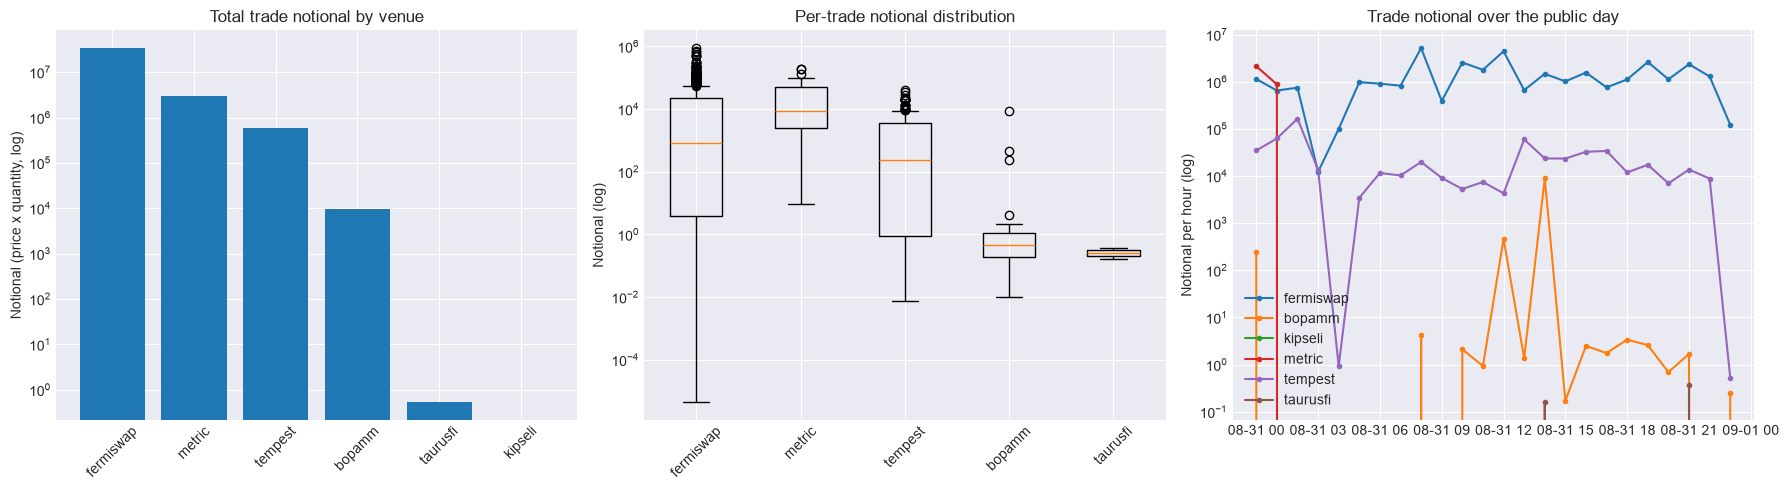

,pairs_observed
source,
fermiswap,"USDC -> USDT, USDC -> WBTC, USDC -> WETH, USDC -> cbBTC, USDT -> USDC, USDT -> WBTC, USDT -> WET..."
bopamm,"USDC -> WBTC, USDC -> WETH, WBTC -> USDC, WBTC -> WETH, WETH -> USDC, WETH -> WBTC"
kipseli,"USDC -> WBTC, USDC -> WETH, WBTC -> USDC, WETH -> USDC"
metric,"0x6c3e…a0e8 -> USDC, 0x8292…17ed -> USDC, USDC -> 0x6c3e…a0e8, USDC -> 0x8292…17ed, USDC -> USDT..."
tempest,"USDC -> USDT, USDC -> WETH, USDT -> USDC, USDT -> WETH, WETH -> USDC, WETH -> USDT"
taurusfi,"USDC -> WBTC, USDC -> WETH, WBTC -> USDC, WETH -> USDC"


In [9]:
hourly = (
    trades_df.assign(hour=trades_df["timestamp"].dt.floor("h"))
    .groupby(["source", "hour"])["notional"]
    .sum()
    .unstack("source")
    .reindex(columns=sources)
    .fillna(0.0)
)

box_data, box_labels = [], []
for source in volume_summary.index:
    values = trades_df.loc[trades_df["source"].eq(source), "notional"].dropna().values
    if len(values):
        box_data.append(values)
        box_labels.append(source)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(volume_summary.index, volume_summary["total_notional"])
axes[0].set_yscale("log")
axes[0].set_title("Total trade notional by venue")
axes[0].set_ylabel("Notional (price x quantity, log)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].boxplot(box_data, tick_labels=box_labels)
axes[1].set_yscale("log")
axes[1].set_title("Per-trade notional distribution")
axes[1].set_ylabel("Notional (log)")
axes[1].tick_params(axis="x", rotation=45)

for source in hourly.columns:
    axes[2].plot(hourly.index, hourly[source], marker=".", label=source)
axes[2].set_yscale("log")
axes[2].set_title("Trade notional over the public day")
axes[2].set_ylabel("Notional per hour (log)")
axes[2].legend()

plt.tight_layout()
plt.show()

pair_presence = pd.DataFrame(
    [
        {"source": source, "pairs_observed": ", ".join(f"{a} -> {b}" for a, b in sorted(pair_sets_by_source[source]))}
        for source in sources
    ]
).set_index("source")
pair_presence